# SOC 2026 — Week 4 Assignment
## Predicting Vigenere Cipher Key Length using Bidirectional LSTM

This notebook implements a Bidirectional LSTM network in PyTorch to predict the length of a Vigenere cipher key (between 1 and 5) from a 100-character sequence of ciphertext.

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import os
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import gutenberg

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [29]:
alphabet = ['a','b','c','d','e','f','g','h','i','j','k','l','m',
            'n','o','p','q','r','s','t','u','v','w','x','y','z',
            ' ','.', ',',';',':','/', '@']
N = len(alphabet)
char_to_idx = {ch: idx for idx, ch in enumerate(alphabet)}
idx_to_char = {idx: ch for idx, ch in enumerate(alphabet)}

# Load austen-emma and persuasion texts from NLTK
nltk.download('gutenberg')
raw_text = gutenberg.raw('austen-emma.txt') + gutenberg.raw('austen-persuasion.txt')
raw_text = raw_text.lower()

# Clean text: keep only symbols in our alphabet
text = "".join(ch for ch in raw_text if ch in char_to_idx)
print(f"Cleaned text length: {len(text)} characters")
print("Sample text:", text[:100])

Cleaned text length: 1309687 characters
Sample text: emma by jane austen volume ichapter iemma woodhouse, handsome, clever, and rich, with a comfortable 


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\abhin\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [30]:
def vigenere_encrypt(plaintext, key):
    ciphertext = []
    for i, ch in enumerate(plaintext):
        shift = char_to_idx[key[i % len(key)]]
        new_idx = (char_to_idx[ch] + shift) % N
        ciphertext.append(idx_to_char[new_idx])
    return "".join(ciphertext)

test_plain = "hello world"
test_key = "abc"
test_cipher = vigenere_encrypt(test_plain, test_key)
print(f"Plaintext:  '{test_plain}'")
print(f"Key:        '{test_key}'")
print(f"Ciphertext: '{test_cipher}'")

Plaintext:  'hello world'
Key:        'abc'
Ciphertext: 'hfnlp,wptle'


In [31]:
part_len = len(text) // 5
parts = [text[i * part_len : (i + 1) * part_len] for i in range(5)]

BLOCK_LEN = 100
X_data = []
y_data = []

random.seed(42)
np.random.seed(42)

for part_idx, part_text in enumerate(parts):
    n = part_idx + 1
    # Slice part_text into 100-character blocks
    blocks = [part_text[i : i + BLOCK_LEN] for i in range(0, len(part_text) - BLOCK_LEN, BLOCK_LEN)]
    
    for block in blocks:
        # Generate a random key of length n
        key = "".join(random.choice(alphabet) for _ in range(n))
        cipher = vigenere_encrypt(block, key)
        
        # One-hot encode the cipher
        one_hot = np.zeros((BLOCK_LEN, N), dtype=np.float32)
        for i, ch in enumerate(cipher):
            one_hot[i, char_to_idx[ch]] = 1.0
        X_data.append(one_hot)
        y_data.append(part_idx)

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.int64)

print(f"X_data shape: {X_data.shape}")
print(f"y_data shape: {y_data.shape}")
print(f"Label distribution: {np.bincount(y_data)}")

X_data shape: (13095, 100, 33)
y_data shape: (13095,)
Label distribution: [2619 2619 2619 2619 2619]


In [32]:
class VigenereDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

indices = np.random.permutation(len(X_data))
split = int(0.8 * len(X_data))
train_idx, val_idx = indices[:split], indices[split:]

train_dataset = VigenereDataset(X_data[train_idx], y_data[train_idx])
val_dataset = VigenereDataset(X_data[val_idx], y_data[val_idx])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Train samples: 10476, Validation samples: 2619


In [33]:
class VigenereKeyLenPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(2, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        # Use output of the last time step
        out = self.fc(out[:, -1, :])
        return out

model = VigenereKeyLenPredictor(input_size=N, hidden_size=128, num_classes=5).to(device)
print(model)

VigenereKeyLenPredictor(
  (lstm): LSTM(33, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)


In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
        
    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total * 100
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    
    model.eval()
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += len(y_batch)
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = val_correct / val_total * 100
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch 01/10 | Train Loss: 1.6103 | Train Acc: 19.07% | Val Loss: 1.6101 | Val Acc: 19.55%
Epoch 02/10 | Train Loss: 1.6089 | Train Acc: 21.12% | Val Loss: 1.6099 | Val Acc: 19.59%
Epoch 03/10 | Train Loss: 1.6076 | Train Acc: 21.63% | Val Loss: 1.6108 | Val Acc: 19.89%
Epoch 04/10 | Train Loss: 1.6058 | Train Acc: 22.45% | Val Loss: 1.6110 | Val Acc: 20.39%
Epoch 05/10 | Train Loss: 1.6040 | Train Acc: 22.87% | Val Loss: 1.6133 | Val Acc: 20.16%
Epoch 06/10 | Train Loss: 1.6021 | Train Acc: 23.34% | Val Loss: 1.6177 | Val Acc: 19.43%
Epoch 07/10 | Train Loss: 1.6221 | Train Acc: 22.64% | Val Loss: 1.6123 | Val Acc: 20.43%
Epoch 08/10 | Train Loss: 1.6012 | Train Acc: 23.85% | Val Loss: 1.6147 | Val Acc: 19.51%
Epoch 09/10 | Train Loss: 1.6000 | Train Acc: 24.21% | Val Loss: 1.6164 | Val Acc: 19.85%
Epoch 10/10 | Train Loss: 1.5984 | Train Acc: 24.28% | Val Loss: 1.6178 | Val Acc: 19.47%


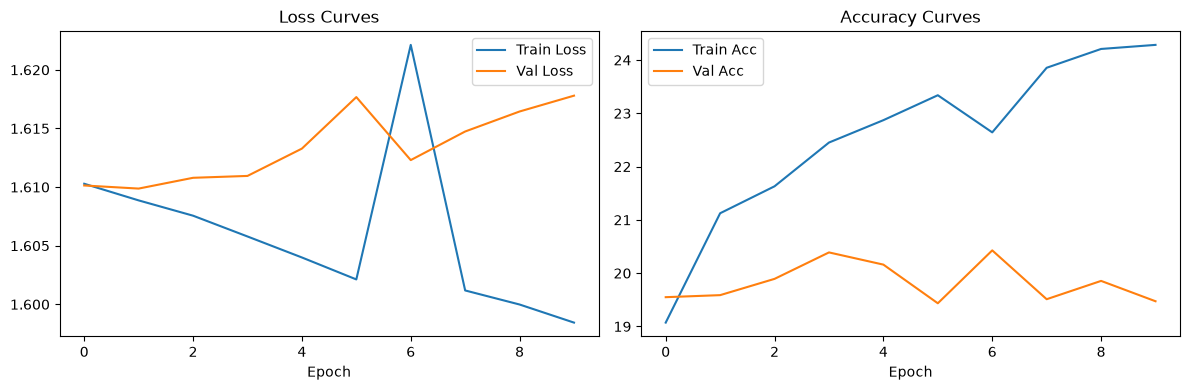

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [36]:
def predict_key_len(plaintext, key):
    cipher = vigenere_encrypt(plaintext, key)
    if len(cipher) < BLOCK_LEN:
        cipher = cipher + " " * (BLOCK_LEN - len(cipher))
    else:
        cipher = cipher[:BLOCK_LEN]
        
    one_hot = np.zeros((BLOCK_LEN, N), dtype=np.float32)
    for i, ch in enumerate(cipher):
        if ch in char_to_idx:
            one_hot[i, char_to_idx[ch]] = 1.0
            
    x = torch.tensor([one_hot]).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(x)
        pred_idx = torch.argmax(outputs, dim=1).item()
        pred_len = pred_idx + 1
        
    print(f"Plaintext:  '{plaintext[:40]}...'")
    print(f"Key:        '{key}' (actual length: {len(key)})")
    print(f"Predicted length: {pred_len}")
    print(f"Match:      {'✅' if pred_len == len(key) else '❌'}")
    print()

test_p = "the quick brown fox jumps over the lazy dog and many other words to make it long enough"
predict_key_len(test_p, "g")
predict_key_len(test_p, "go")
predict_key_len(test_p, "gem")
predict_key_len(test_p, "cool")
predict_key_len(test_p, "hello")

Plaintext:  'the quick brown fox jumps over the lazy ...'
Key:        'g' (actual length: 1)
Predicted length: 4
Match:      ❌

Plaintext:  'the quick brown fox jumps over the lazy ...'
Key:        'go' (actual length: 2)
Predicted length: 4
Match:      ❌

Plaintext:  'the quick brown fox jumps over the lazy ...'
Key:        'gem' (actual length: 3)
Predicted length: 4
Match:      ❌

Plaintext:  'the quick brown fox jumps over the lazy ...'
Key:        'cool' (actual length: 4)
Predicted length: 4
Match:      ✅

Plaintext:  'the quick brown fox jumps over the lazy ...'
Key:        'hello' (actual length: 5)
Predicted length: 4
Match:      ❌

